# Data

> Data classes and functions

In [1]:
#| default_exp data

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
#| export

from fastai.vision.all import *
from fastai.data.all import *
from torchio import ScalarImage, ToCanonical, Resample
import multipagetiff as mtif


## Utilities

### Tiff reader

In [4]:
#| export

def tiff_reader(path, units='um'):
    stack = mtif.read_stack(path, units=units)
    data = stack.pages.astype(np.float32)
    data = data[None, :, :, :]
    affine = np.eye(4) # to be changed
    return data, affine

### Lif reader

In [5]:
#| export
from aicsimageio import AICSImage

def lif_reader(path, units='um'):
    imagen_aics = AICSImage(file_path_2)
    data = imagen_aics.get_image_data()
    data = np.squeeze(data,0)
    affine = np.eye(4)
    return data, affine

In [42]:
from aicsimageio.readers import CziReader

# Get reader
reader = CziReader('../../bioMONAI_0/_data/Babesia_new/MouseBrain_41Slices_1Tile_1Channel_2Illuminations_2Angles.czi')

print(type(reader.data))  
print(type(reader.dims))  
print(type(reader.shape))
print()


# Get an AICSImage object
img = AICSImage('../../bioMONAI_0/_data/Babesia_new/MouseBrain_41Slices_1Tile_1Channel_2Illuminations_2Angles.czi')
print(type(img.data))  
print(type(img.dims))
print(type(img.shape))
print()

<class 'numpy.ndarray'>
<class 'aicsimageio.dimensions.Dimensions'>
<class 'tuple'>

<class 'numpy.ndarray'>
<class 'aicsimageio.dimensions.Dimensions'>
<class 'tuple'>



In [43]:
file_path = '../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff'

d, _ = tiff_reader(file_path)
print(d.shape)
print(type(d))

(1, 96, 512, 512)
<class 'numpy.ndarray'>


In [7]:
file_path_2 = '../../bioMONAI_0/_data/Babesia_new/Sample_02/Stellaris/Reflection+Fluo_20221205/2022-12-05.lif'

e, _ = lif_reader(file_path_2, units='um')

print(e.shape)
print(type(e))

(4, 17, 256, 1024)
<class 'numpy.ndarray'>


### Preprocessing

In [8]:
#| export

def _preprocess(obj, reorder, resample):
    """
    Preprocesses the given object.

    Args:
        obj: The object to preprocess.
        reorder: Whether to reorder the object.
        resample: Whether to resample the object.

    Returns:
        The preprocessed object and its original size.
    """
    if reorder:
        transform = ToCanonical()
        obj = transform(obj)

    original_size = obj.shape[1:]

    if resample and not all(np.isclose(obj.spacing, resample)):
        transform = Resample(resample)
        obj = transform(obj)

    # if MedBase.affine_matrix is None:
    #     MedBase.affine_matrix = obj.affine

    return obj, original_size



### Load and preprocess

In [105]:
#| export

def _load_and_preprocess(file_path, reorder=False, resample=False, reader=tiff_reader):
    """
    Helper function to load and preprocess an image.

    Args:
        file_path: Image file path.
        reorder: Whether to reorder data for canonical (RAS+) orientation.
        resample: Whether to resample image to different voxel sizes and dimensions.
        dtype: Desired datatype for output.

    Returns:
        tuple: Original image, preprocessed image, and its original size.
    """
    org_img = ScalarImage(file_path, reader=reader)
    input_img, org_size = _preprocess(org_img, reorder, resample)
    
    return org_img, input_img, org_size

In [134]:

# load and process tiif file
# t_1 = _load_and_preprocess(file_path, reader = tiff_reader)

# load and process lif file
# t_2 = _load_and_preprocess(file_path_2, reader=lif_reader)

### Read multichannel data

In [135]:
#| export

def _multi_channel(image_paths: (L, list), reorder: bool = False, resample: list = None, dtype=torch.Tensor, only_tensor: bool = True, squeeze: bool = False):
    """
    Load and preprocess multisequence data.

    Args:
        image_paths: List of image paths (e.g., T1, T2, T1CE, DWI).
        reorder: Whether to reorder data for canonical (RAS+) orientation.
        resample: Whether to resample image to different voxel sizes and dimensions.
        dtype: Desired datatype for output.
        only_tensor: Whether to return only image tensor.

    Returns:
        torch.Tensor: A stacked 4D tensor, if `only_tensor` is True.
        tuple: Original image, preprocessed image, original size, if `only_tensor` is False.
    """
    image_data = [_load_and_preprocess(image, reorder, resample) for image in image_paths]
    org_img, input_img, org_size = image_data[-1]

    tensor = torch.stack([img.data[0] for _, img, _ in image_data], dim=0)
    
    if only_tensor:     
        if squeeze:
            return torch.squeeze(dtype(tensor))
        return dtype(tensor) 

    input_img.set_data(tensor)
    return org_img, input_img, org_size


In [136]:
file_names = get_image_files('../../bioMONAI-main_0/_data/Babesia/TRITC')#'../_data/Babesia/TRITC'
_multi_channel(file_names);

IndexError: list index out of range

### Image reader

In [137]:
#| export

def img_reader(file_path: (str, Path, L, list), dtype=torch.Tensor, reorder: bool = False,
                   resample: list = None, only_tensor: bool = True):
    """Loads and preprocesses a medical image.

    Args:
        file_path: Path to the image. Can be a string, Path object or a list.
        dtype: Datatype for the return value. Defaults to torch.Tensor.
        reorder: Whether to reorder the data to be closest to canonical 
            (RAS+) orientation. Defaults to False.
        resample: Whether to resample image to different voxel sizes and 
            image dimensions. Defaults to None.
        only_tensor: W2022-12-05.lifhether to return only image tensor. Defaults to True.

    Returns:
        The preprocessed image. Returns only the image tensor if 
        only_tensor is True, otherwise returns original image, 
        preprocessed image, and original size.
    """
    # if isinstance(file_path, str) and ';' in file_path:
    #     return _multi_channel(
    #         file_path.split(';'), reorder, resample, dtype, only_tensor)
    
    if isinstance(file_path, (L, list)):
        return _multi_channel(file_path, reorder, resample, dtype, only_tensor)

    org_img, input_img, org_size = _load_and_preprocess(
        file_path, reorder, resample)

    if only_tensor:
        return dtype(input_img.data.type(torch.float))

    return org_img, input_img, org_size


In [138]:
# img_reader(file_names)

## Data types

### Meta resolver

In [139]:
#| export

class MetaResolver(type(torch.Tensor), metaclass=BypassNewMeta):
    """
    A class to bypass metaclass conflict:
    https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/data/batch.html
    """
    pass


### BioImageBase

In [140]:
#| export

from bioMONAI.core import show_images_grid, mosaic_image_3d
from monai.data import MetaTensor


In [141]:

#| export
class BioImageBase(MetaTensor, metaclass=MetaResolver):
    """
    A class that represents an image object.
    Metaclass casts `x` to this class if it is of type `cls._bypass_type`.
    """
    
    _bypass_type = torch.Tensor  # The type that bypasses image loading
    _show_args = {'cmap': 'gray'}  # Default arguments for image display
    resample, reorder = None, False  # Default resample and reorder settings
    affine_matrix = None  # Default affine matrix for image transformation

    @classmethod
    def create(cls, fn: (Path, str, List, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 4D tensor as a BioImageBase object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)

    @classmethod
    def item_preprocessing(cls, resample: (List, int, tuple), reorder: bool):
        """
        Changes the values for the class variables `resample` and `reorder`.

        Args:
            resample : (List, int, tuple)
                A list with voxel spacing.
            reorder : bool
                Whether to reorder the data to be closest to canonical (RAS+) orientation.
        """
        cls.resample = resample
        cls.reorder = reorder

    def show(self, ctx=None, figsize: int = None, ncols: int = 10, **kwargs):
        """
        Plots 2D slices of a 3D image alongside a prior specified axis.

        Args:
            ctx : Context to use for the display. Defaults to None.
            figsize: Size of the figure. Defaults to None.
            ncols: Number of columns in the grid. Defaults to 10.
            **kwargs : Additional keyword arguments passed to plt.imshow.

        Returns:
            Shown image.
        """
        return show_images_grid(self, ctx=ctx, ncols=ncols, **merge(self._show_args, kwargs))
    
    def as_tensor(self) -> torch.Tensor:
        """
        Return the `MetaTensor` as a `torch.Tensor`.
        It is OS dependent as to whether this will be a deep copy or not.
        """
        return self.as_subclass(torch.Tensor)

    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageBase{self.as_tensor().__repr__()[6:]}"

### BioImage 

class for 2D Images

In [142]:
#| export

class BioImage(BioImageBase):
    """Subclass of BioImageBase that represents 2D and 3D image objects."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
    #     return f'{self.__class__.__name__} shape={"x".join([str(d) for d in self.shape])}'
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [143]:
a = BioImage.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
print(a.shape)
a = BioImage.create('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')
a.shape

torch.Size([1, 96, 512, 512])


torch.Size([1, 512, 512])

### BioImageStack

class for 3D images

In [23]:
#| export

class BioImageStack(BioImageBase):
    """Subclass of BioImageBase that represents a 3D image object."""
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageStack{self.as_tensor().__repr__()[6:]}"

In [25]:
a = BioImageStack.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
print(a.shape)
a = BioImageStack.create('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')
a.shape

torch.Size([1, 96, 512, 512])


torch.Size([1, 1, 512, 512])

### BioImageProject

2D representations of 3D stack using maximum intensity projection

In [26]:
#| export

class BioImageProject(BioImageBase):
    """Subclass of BioImageBase that represents a 2D image object."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        img = img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)
        return torch.max(img, dim=1)[0]  # Taking the maximum intensity projection along axis 1
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [28]:
a = BioImageProject.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
a.shape

torch.Size([1, 512, 512])

### BioImageMulti

Multichannel datasets

In [29]:
#| export

class BioImageMulti(BioImageBase):
    """Subclass of BioImageBase that represents a multi-channel 2D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 0)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageMulti{self.as_tensor().__repr__()[6:]}"

torch.Size([96, 512, 512])


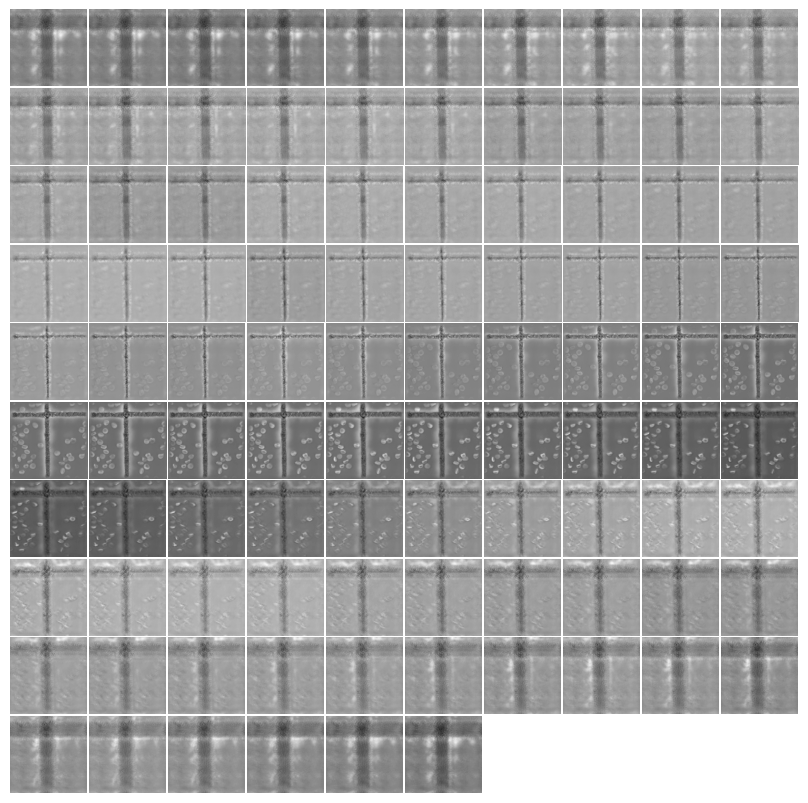

In [39]:
a = BioImageMulti.create('../_data/Babesia/RI/O11_RI_frame01.tiff')
print(a.shape)

### BioImage4D

4D datasets

In [24]:
# TO DO

### Data conversion

In [25]:
#| export

class Tensor2BioImage(DisplayedTransform):
    def __init__(self, cls:BioImageBase=BioImageStack):
        self.cls = cls

    def encodes(self, o):
        if isinstance(o, MetaTensor):
            return self.cls(o.clone(), affine=o.affine, meta=o.meta)
        
        if isinstance(o, torch.Tensor):
            return self.cls(o)

## Data blocks

### ImageBlock

In [26]:
#| export

def BioImageBlock(cls:BioImageBase=BioImageStack):
    "A `TransformBlock` for images of `cls`"
    return TransformBlock(type_tfms=cls.create, batch_tfms=[Tensor2BioImage(cls)]) # IntToFloatTensor

## Display

### Show batch

In [27]:
#| export 

@typedispatch
def show_batch(x:BioImageBase, y:BioImageBase, samples, ctxs=None, max_n=10, nrows=None, ncols=None, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    for i in range(2):
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::2],range(max_n))]
    return ctxs

### Show results

In [28]:
#| export 

@typedispatch
def show_results(x:BioImageBase, y:BioImageBase, samples, outs, ctxs=None, max_n=10, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(3*min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::3],range(max_n))]
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(outs.itemgot(0),ctxs[2::3],range(max_n))]
    return ctxs

## Example

In [29]:
from monai.transforms import ScaleIntensity
from bioMONAI.transforms import *

spatial_dimensions = 2
roi_size = [32]*spatial_dimensions
item_tfms = [RandCropND(roi_size), ScaleIntensity] 

Setting affine, but the applied meta contains an affine. This will be overwritten.


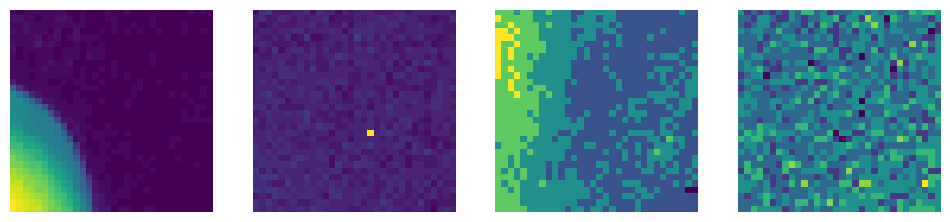

In [34]:
from bioMONAI.core import get_target

file_folder = '../_data/Babesia/RI/'

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImageProject)),
                   get_items=get_image_files,
                   get_y=get_target('../_data/Babesia/TRITC', same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                   )
# dblock.summary(file_folder)

dls = dblock.dataloaders(file_folder, bs=2)
dls.show_batch(max_n=2, cmap='viridis')

In [35]:
from monai.networks.nets import DynUNet
from monai.losses import SSIMLoss

In [36]:
model = DynUNet(spatial_dims=spatial_dimensions, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True)

In [37]:
loss_func = SSIMLoss(spatial_dims=spatial_dimensions)

In [38]:
learn = Learner(dls, model, loss_func=loss_func)

In [39]:
learn.summary()

DynUNet (Input shape: 2 x 1 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     2 x 32 x 32 x 32    
Conv2d                                    288        True      
Conv2d                                    9216       True      
LeakyReLU                                                      
InstanceNorm2d                            64         True      
InstanceNorm2d                            64         True      
Conv2d                                    32         True      
InstanceNorm2d                            64         True      
____________________________________________________________________________
                     2 x 64 x 16 x 16    
Conv2d                                    18432      True      
Conv2d                                    36864      True      
LeakyReLU                                                      
InstanceNorm2d                            128        True      
InstanceNorm2d                  

In [40]:
learn.fit_flat_cos(5,1e-3)

epoch,train_loss,valid_loss,time
0,0.260365,0.093399,00:13
1,0.094323,0.069920,00:13
2,0.085315,0.075575,00:13
3,0.067609,0.046089,00:13
4,0.058050,0.051263,00:13


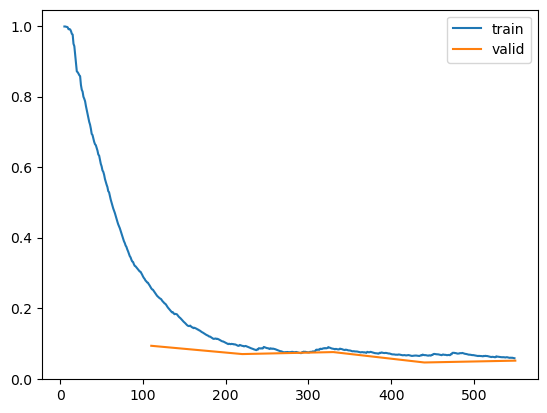

In [41]:
learn.recorder.plot_loss()

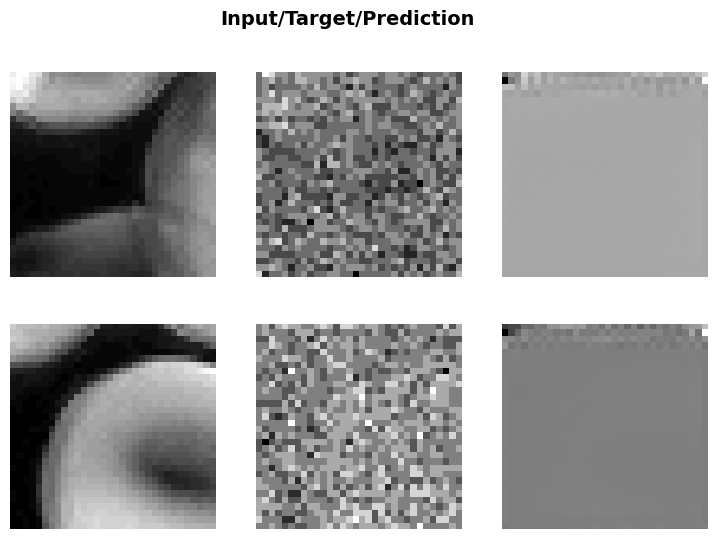

In [42]:
learn.show_results(cmap='gray')

In [34]:
#| hide
import nbdev; nbdev.nbdev_export()